In [115]:
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio

In [116]:
np.random.seed(2026)
pd.options.display.float_format = '{:,.5f}'.format
pio.renderers.default = 'vscode'

In [117]:
data = pd.read_csv('data/Groceries_dataset.csv')
data.sample(50)

,Member_number,Date,itemDescription
20940,4204,16-10-2015,rolls/buns
3846,1721,15-10-2015,other vegetables
31829,3011,16-08-2014,salty snack
9986,2616,24-10-2014,root vegetables
6249,2171,22-04-2015,beef
6242,3167,20-08-2015,soda
10685,2437,09-10-2014,root vegetables
32641,4022,24-04-2015,soda
12796,2917,27-05-2014,yogurt
15186,3487,22-05-2014,whipped/sour cream


In [118]:
data.isna().sum()

Member_number      0
Date               0
itemDescription    0
dtype: int64

In [119]:
data['Date'] = pd.to_datetime(data['Date'], dayfirst = True)
data = data.sort_values(by = 'Date')

In [120]:
data['Month'] = data['Date'].dt.to_period('M').dt.to_timestamp()

monthly_counts = data.groupby('Month').size().reset_index(name = 'Purchase Count')

fig = px.area(monthly_counts, x = 'Month', y = 'Purchase Count',
              title = 'Purchase Trends Monthly',
              labels = {'Month': 'Month', 'Purchase Count': 'Number of Purchases'},
              template = 'plotly_white')

fig.show()

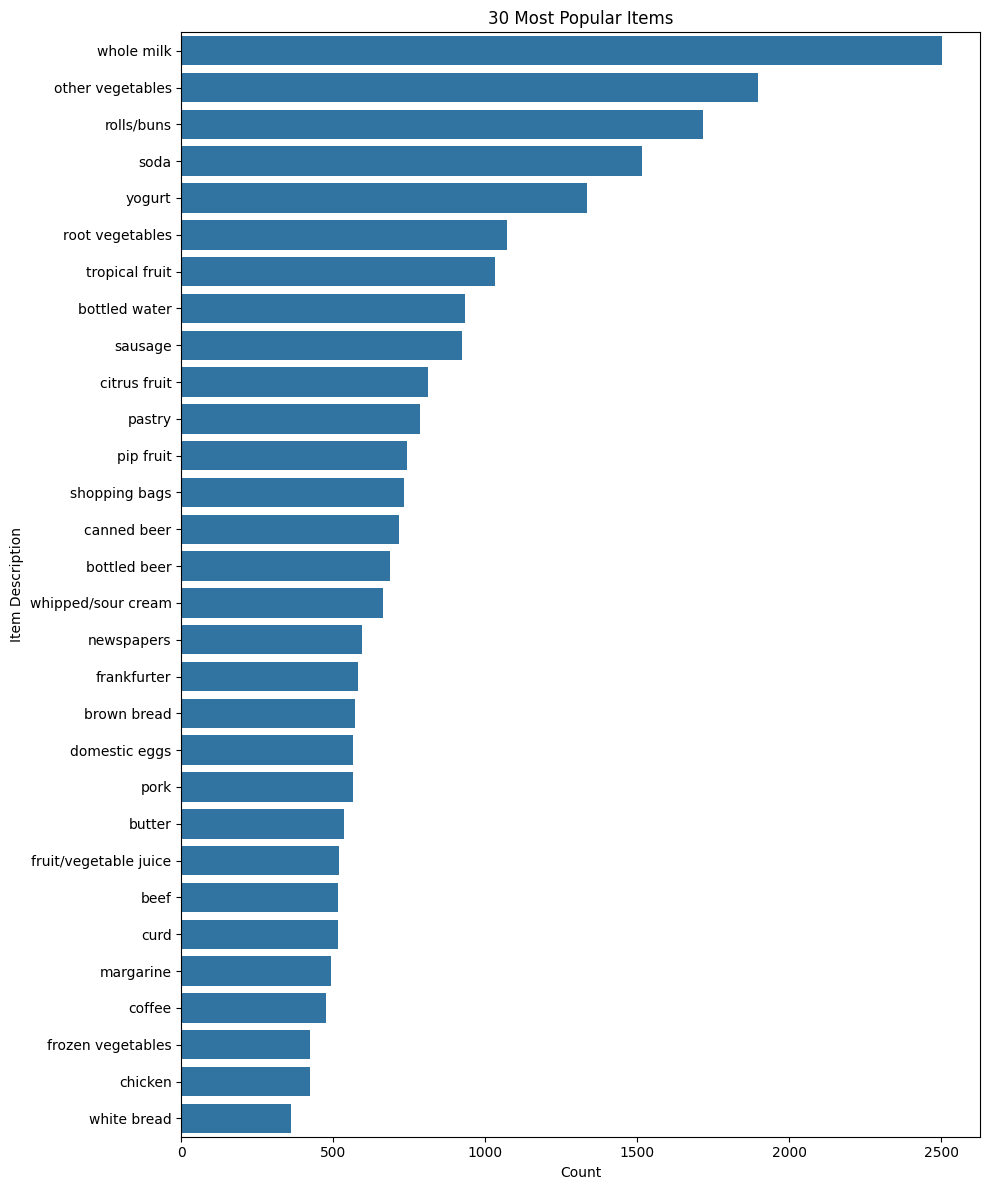

In [121]:
popular_items = data['itemDescription'].value_counts()[:30]

plt.figure(figsize = (10, 12))
sns.barplot(x = popular_items.values, y = popular_items.index)
plt.title("30 Most Popular Items")
plt.xlabel('Count')
plt.ylabel('Item Description')
plt.tight_layout()

plt.show()

In [122]:
data['Month'] = data['Date'].dt.to_period('M').astype(str)

monthly_item_counts = data.groupby(['Month', 'itemDescription']).size().reset_index(name = 'Count')
top_items_per_month = monthly_item_counts.sort_values(['Month', 'Count'], ascending = [True, False]).groupby('Month').first().reset_index()

fig = px.bar(
    top_items_per_month,
    x = 'Month',
    y = 'Count',
    text = 'itemDescription',
    title = 'Most Popular Items per Month',
    labels = {'Count': 'Popularity', 'Month': 'Month'},
    template = 'plotly_white'
)

fig.update_traces(textposition = 'outside')

fig.update_layout(
    xaxis_tickangle = -45,
    yaxis_title = 'Number of Occurrences',
    xaxis_title = 'Month',
    uniformtext_minsize = 8,
    uniformtext_mode = 'hide',
    margin = dict(l = 40, r = 40, t = 60, b = 100),
    height = 500
)

fig.show()

In [123]:
grouped_data = data.groupby(['Date', 'Member_number'])['itemDescription'].apply(list).reset_index()
grouped_data

,Date,Member_number,itemDescription
0,2014-01-01,1249,"[coffee, citrus fruit]"
1,2014-01-01,1381,"[curd, soda]"
2,2014-01-01,1440,"[other vegetables, yogurt]"
3,2014-01-01,1659,"[frozen vegetables, specialty chocolate]"
4,2014-01-01,1789,"[candles, hamburger meat]"
...,...,...,...
14958,2015-12-30,3738,"[flour, onions]"
14959,2015-12-30,3971,"[bottled beer, brown bread]"
14960,2015-12-30,4058,"[cream cheese , domestic eggs]"
14961,2015-12-30,4565,"[canned beer, canned beer]"


In [124]:
transactions = grouped_data['itemDescription'].tolist()
transactions[:20]

[['coffee', 'citrus fruit'],
 ['curd', 'soda'],
 ['other vegetables', 'yogurt'],
 ['frozen vegetables', 'specialty chocolate'],
 ['candles', 'hamburger meat'],
 ['tropical fruit', 'other vegetables'],
 ['bottled water', 'sausage'],
 ['Instant food products', 'bottled water'],
 ['shopping bags', 'cleaner'],
 ['sliced cheese', 'bottled water'],
 ['domestic eggs', 'bottled beer', 'hamburger meat'],
 ['yogurt', 'frozen vegetables'],
 ['frozen potato products', 'hamburger meat'],
 ['whole milk', 'flower (seeds)'],
 ['bottled water', 'whipped/sour cream', 'berries'],
 ['dishes', 'onions', 'whipped/sour cream'],
 ['waffles', 'whole milk'],
 ['Instant food products', 'other vegetables', 'yogurt'],
 ['shopping bags', 'waffles', 'chocolate', 'yogurt'],
 ['brown bread', 'soda']]

In [125]:
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df_encoded = pd.DataFrame(te_ary, columns = te.columns_)
df_encoded

,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,bags,baking powder,bathroom cleaner,beef,berries,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14958,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
14959,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
14960,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
14961,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [128]:
frequent_itemsets = apriori(df_encoded, min_support = 0.001, use_colnames = True)
display(frequent_itemsets.sort_values(by = 'support', ascending = False))

,support,itemsets
146,0.15792,frozenset({whole milk})
90,0.12210,frozenset({other vegetables})
109,0.11000,frozenset({rolls/buns})
123,0.09711,frozenset({soda})
147,0.08588,frozenset({yogurt})
...,...,...
162,0.00100,"frozenset({beef, canned beer})"
34,0.00100,frozenset({cooking chocolate})
105,0.00100,frozenset({ready soups})
725,0.00100,"frozenset({tropical fruit, sugar})"


In [129]:
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(lambda x: len(x))
print(frequent_itemsets[frequent_itemsets['length'] > 1])

     support                                      itemsets  length
149  0.00107          frozenset({UHT-milk, bottled water})       2
150  0.00214       frozenset({other vegetables, UHT-milk})       2
151  0.00180             frozenset({rolls/buns, UHT-milk})       2
152  0.00100        frozenset({UHT-milk, root vegetables})       2
153  0.00114                frozenset({sausage, UHT-milk})       2
..       ...                                           ...     ...
745  0.00114  frozenset({whole milk, sausage, rolls/buns})       3
746  0.00100     frozenset({whole milk, rolls/buns, soda})       3
747  0.00134   frozenset({whole milk, rolls/buns, yogurt})       3
748  0.00107        frozenset({whole milk, sausage, soda})       3
749  0.00147      frozenset({whole milk, sausage, yogurt})       3

[601 rows x 3 columns]


In [130]:
rules = association_rules(frequent_itemsets, metric = 'confidence', min_threshold = 0.05)
rules_simple = rules[['antecedents', 'consequents','support', 'confidence', 'lift']]
rules_simple = rules_simple.sort_values(by='confidence', ascending=False)
rules_simple = rules_simple[rules_simple['lift'] > 1.25]
display(rules_simple)

,antecedents,consequents,support,confidence,lift
449,"frozenset({sausage, yogurt})",frozenset({whole milk}),0.00147,0.25581,1.61987
437,"frozenset({sausage, rolls/buns})",frozenset({whole milk}),0.00114,0.21250,1.34559
447,"frozenset({whole milk, sausage})",frozenset({yogurt}),0.00147,0.16418,1.91176
332,frozenset({processed cheese}),frozenset({rolls/buns}),0.00147,0.14474,1.31573
311,frozenset({packaged fruit/vegetables}),frozenset({rolls/buns}),0.00120,0.14173,1.28842
340,frozenset({seasonal products}),frozenset({rolls/buns}),0.00100,0.14151,1.28639
448,"frozenset({whole milk, yogurt})",frozenset({sausage}),0.00147,0.13174,2.18292
402,frozenset({soft cheese}),frozenset({yogurt}),0.00127,0.12667,1.47495
157,frozenset({detergent}),frozenset({yogurt}),0.00107,0.12403,1.44426
100,frozenset({chewing gum}),frozenset({yogurt}),0.00140,0.11667,1.35851


In [131]:
rules_simple['antecedents_str'] = rules_simple['antecedents'].apply(
    lambda x: ', '.join(list(x)))
rules_simple['consequents_str'] = rules_simple['consequents'].apply(
    lambda x: ', '.join(list(x)))

fig = px.scatter(
    rules_simple,
    x="support",
    y="confidence",
    size="lift",
    color="lift",
    color_continuous_scale="Emrld",
    hover_data={
        "antecedents_str": True,
        "consequents_str": True,
        "support": False,
        "confidence": False,
        "lift": True
    },
    labels={
        "support": "Support",
        "confidence": "Confidence",
        "lift": "Lift",
        "antecedents_str": "Antecedents",
        "consequents_str": "Consequents"
    },
    title="Support vs Confidence"
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5
    
)

fig.show()